In [1]:
import spei
import inspect

# Ver la firma de la función
print(inspect.signature(spei.spei))

# Ver la documentación
print(spei.spei.__doc__)

(series: pandas.core.series.Series, dist: Union[Any, scipy.stats._distn_infrastructure.rv_continuous] = <scipy.stats._continuous_distns.fisk_gen object at 0x7164709bc400>, timescale: int = 0, fit_freq: str | None = None, fit_window: int = 0, prob_zero: bool = False) -> pandas.core.series.Series
Method to compute the Standardized Precipitation Evaporation Index.

    Parameters
    ----------
    series: pandas.Series
        Pandas time series of the precipitation. Time series index
        should be a pandas DatetimeIndex.
    dist: scipy.stats.rv_continuous
        Can be any continuous distribution from the scipy.stats library.
        However, for the SPEI generally the log-logistic (fisk) probability
        density function is recommended. Other appropriate choices could be
        the lognormal or PearsonIII distribution.
    timescale : int, optional, default=0
        Size of the moving window over which the series is summed. If zero, no
        summation is performed over the

In [2]:
"""
Calculates the Standardized Precipitation Evapotranspiration Index (SPEI)
for a point, using CHIRPS (precipitation) and ERA5-Land (temperature) data
via Google Earth Engine.

The SPEI (Vicente-Serrano et al., 2010) is a multi-scalar drought index that
combines precipitation and potential evapotranspiration to characterize
wet and dry conditions. Unlike SPI (which only uses precipitation), SPEI
incorporates temperature, making it sensitive to climate change effects
on water demand.

HOW TO READ THE RESULT
-----------------------
spei_1m    Short-term moisture conditions (last ~1 month)
           Captures immediate water stress during crop establishment.

spei_3m    Seasonal drought context (last ~3 months)
           Indicates whether the growing season has been dry or wet.

spei_6m    Medium-term agricultural drought (last ~6 months)
           Reflects cumulative water deficit over the crop cycle.

spei_12m   Long-term hydrological drought (last ~12 months)
           Distinguishes between chronic dry zones and occasional dry years.

SPEI values interpretation:
    >  2.0  : Extremely wet
     1.5 to 2.0 : Severely wet
     1.0 to 1.5 : Moderately wet
    -1.0 to 1.0 : Near normal
    -1.5 to -1.0: Moderately dry
    -2.0 to -1.5: Severely dry
    < -2.0 : Extremely dry

REFERENCE:
Vicente-Serrano, S.M., Beguería, S., & López-Moreno, J.I. (2010).
A multi-scalar drought index sensitive to global warming: The Standardized
Precipitation Evapotranspiration Index. Journal of Climate, 23(7), 1696–1718.
https://doi.org/10.1175/2009JCLI2909.1

PACKAGE REQUIREMENTS:
This script uses the 'spei' Python package for official SPEI calculation.

Installation:
    pip install spei

The package implements the full methodology from Vicente-Serrano et al. (2010),
including:
    - Log-logistic distribution fitting for the water balance (P - PET)
    - Unbiased probability weighted moments (PWM) for parameter estimation
    - Standardization to a standard normal distribution (mean=0, std=1)
    - Multiple time scales (1, 3, 6, 12, 24 months)

USAGE EXAMPLE:
    import spei
    
    # water_balance is a 1D Pandas Series of P - PET values
    spei_values = spei.spei(
        water_balance,
        scale=1,
        distribution='LogLogistic',
        fit='lmoments'
    )
"""
from datetime import date, datetime, timedelta
from pathlib import Path
import math
import pandas as pd
import numpy as np
import ee
# Initialize the Earth Engine API (must be called before any EE operations)
ee.Initialize()

# SPEI package for official calculation
# https://github.com/martinvonk/SPEI
import spei
from scipy.stats import fisk

from period_utils import build_biweekly_periods


def calculate_pet_thornthwaite(temp_c, lat):
    """
    Calculates monthly potential evapotranspiration using the Thornthwaite method.
    
    The Thornthwaite equation requires only mean temperature and latitude,
    making it suitable for global applications where detailed meteorological
    data (radiation, wind, humidity) are not available.
    
    This PET is used as input for the SPEI calculation, following the
    methodology of Vicente-Serrano et al. (2010), who recommend using
    Thornthwaite PET when only temperature data are available.
    
    Args:
        temp_c: Mean temperature in Celsius (monthly or biweekly)
        lat: Latitude in degrees
    
    Returns:
        float: Potential evapotranspiration in mm
    """
    if temp_c is None or temp_c <= 0:
        return 0.0
    
    # Thornthwaite heat index calculation
    # Based on the original 1948 formulation, simplified for monthly/biweekly use
    I = (temp_c / 5) ** 1.514  # Monthly heat index
    
    # Annual heat index (simplified: multiply by 12 for monthly approximation)
    annual_I = I * 12
    
    # Exponent a (empirical function of annual heat index)
    a = (6.75e-7 * annual_I**3) - (7.71e-5 * annual_I**2) + (1.792e-2 * annual_I) + 0.49239
    
    # PET calculation (mm/month)
    # Adjusted for latitude and day length (simplified correction)
    pet_mm = 16 * (10 * temp_c / annual_I) ** a
    
    # Latitude correction for day length (simplified)
    lat_correction = 1.0 + 0.02 * abs(lat) / 90  # Slight increase at higher latitudes
    pet_mm = pet_mm * lat_correction
    
    return pet_mm


from scipy.stats import fisk  # Add this import at the top

def calculate_spei_official(df_water_balance):
    """
    Calculates SPEI using the official 'spei' Python package.
    """
    df_wb = df_water_balance.sort_values('period_start').reset_index(drop=True)
    n_total = len(df_wb)
    
    water_balance_series = pd.Series(
        df_wb['water_balance'].values,
        index=pd.DatetimeIndex(df_wb['period_start'])
    )
    
    spei_results = {}
    
    try:
        for scale_months in [1, 3, 6, 12]:
            timescale = scale_months * 2
            
            spei_values = spei.spei(
                water_balance_series,
                dist=fisk,
                timescale=timescale,
                fit_freq=None,
                fit_window=0,
                prob_zero=False
            )
            
            # Reindex to match the original series length
            # This adds NaN for any missing periods
            spei_aligned = spei_values.reindex(water_balance_series.index)
            spei_results[scale_months] = spei_aligned.values
            
    except Exception as e:
        print(f"[WARNING] Error calculating SPEI with official package: {e}")
        print("[WARNING] Falling back to z-score standardization")
        
        water_balance = df_wb['water_balance'].values
        for scale_months in [1, 3, 6, 12]:
            n_periods = scale_months * 2
            wb_accumulated = pd.Series(water_balance).rolling(
                window=n_periods, min_periods=n_periods
            ).sum()
            spei_results[scale_months] = (wb_accumulated - wb_accumulated.mean()) / wb_accumulated.std()
    
    return spei_results


def get_spei_biweekly(lat, lon, start_date="2016-01-01", end_date=None):
    """
    Calculates SPEI at multiple temporal scales (1, 3, 6, 12 months) for a point.
    
    The SPEI is computed from the water balance (P - PET) accumulated over
    different time windows, then standardized using a log-logistic distribution
    following Vicente-Serrano et al. (2010) via the official 'spei' package.
    
    Args:
        lat: Latitude of the point in degrees
        lon: Longitude of the point in degrees
        start_date: Start date for the analysis period (str "YYYY-MM-DD")
        end_date: End date for the analysis period (str "YYYY-MM-DD");
                  None defaults to today
    
    Returns:
        pandas.DataFrame: SPEI values for each biweekly period with columns:
                          period_start, period_end, label,
                          spei_1m, spei_3m, spei_6m, spei_12m
    """
    # Parse date strings to Python date objects
    start = datetime.strptime(start_date, "%Y-%m-%d").date()
    end = datetime.strptime(end_date, "%Y-%m-%d").date() if end_date else date.today()

    # Generate the list of complete biweekly periods within the date range
    periods = build_biweekly_periods(start, end)
    print(f"[DEBUG] {len(periods)} biweekly periods to process, from {start} to {end}")

    # Create Earth Engine point geometry for the extraction location
    point = ee.Geometry.Point([lon, lat])

    # Load CHIRPS precipitation (mm/day)
    chirps_coll = (
        ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
        .select('precipitation')
        .filterDate(str(start), str(end + timedelta(days=1)))
    )

    # Load ERA5-Land temperature (K) for PET calculation
    era5_coll = (
        ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
        .select('temperature_2m')
        .filterDate(str(start), str(end + timedelta(days=1)))
    )

    # Build the list of periods as an ee.List of dictionaries for server-side mapping
    ee_periods = ee.List([
        {'label': label, 'start': str(p_start), 'end': str(p_end)}
        for label, p_start, p_end in periods
    ])

    def compute_period(period):
        """
        Server-side function to compute P and T for a single period.
        This runs on Google Earth Engine servers, not locally.
        
        Args:
            period: ee.Dictionary with keys 'label', 'start', 'end'
        
        Returns:
            ee.Feature with precipitation sum and mean temperature
        """
        period = ee.Dictionary(period)
        p_start = ee.Date(period.get('start'))
        p_end = ee.Date(period.get('end'))

        # Sum precipitation over the period (mm)
        precip_sum = chirps_coll.filterDate(p_start, p_end).sum().rename('precip_mm')
        
        # Mean temperature over the period (K → C)
        temp_mean = era5_coll.filterDate(p_start, p_end).mean().rename('temp_c')
        temp_c = temp_mean.subtract(273.15)

        # Combine into a single image
        combined = precip_sum.addBands(temp_c)

        # Extract values at the point location
        stats = combined.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=point,
            scale=5566,  # CHIRPS native resolution
            maxPixels=1e9
        )

        return ee.Feature(
            None,
            stats
            .set('label', period.get('label'))
            .set('period_start', p_start.format('YYYY-MM-dd'))
            .set('period_end', p_end.advance(-1, 'day').format('YYYY-MM-dd'))
        )

    # Map the compute_period function over all periods (server-side execution)
    features = ee.FeatureCollection(ee_periods.map(compute_period))
    
    # Single network call to retrieve ALL periods' results at once
    result = features.getInfo()

    # Parse the Earth Engine response into a list of dictionaries
    rows = []
    for f in result['features']:
        props = f['properties']
        rows.append({
            'period_start': props.get('period_start'),
            'period_end': props.get('period_end'),
            'label': props.get('label'),
            'precip_mm': round(props.get('precip_mm'), 2) if props.get('precip_mm') is not None else None,
            'temp_c': round(props.get('temp_c'), 2) if props.get('temp_c') is not None else None,
        })

    # Create DataFrame and sort chronologically
    df = pd.DataFrame(rows)
    df['period_start'] = pd.to_datetime(df['period_start'])
    df = df.sort_values('period_start').reset_index(drop=True)

    # Calculate PET using Thornthwaite method for each period
    df['pet_mm'] = df.apply(
        lambda row: calculate_pet_thornthwaite(row['temp_c'], lat),
        axis=1
    )

    # Calculate water balance (D = P - PET)
    df['water_balance'] = df['precip_mm'] - df['pet_mm']

    # Calculate SPEI using the official package
    # This uses the log-logistic distribution fitting from Vicente-Serrano et al. (2010)
    spei_results = calculate_spei_official(df[['period_start', 'water_balance']])
    
    # Add SPEI values to the DataFrame
    df['spei_1m'] = spei_results[1].round(3)
    df['spei_3m'] = spei_results[3].round(3)
    df['spei_6m'] = spei_results[6].round(3)
    df['spei_12m'] = spei_results[12].round(3)

    # Select final columns for output
    df = df[['period_start', 'period_end', 'label', 
             'precip_mm', 'temp_c', 'pet_mm', 'water_balance',
             'spei_1m', 'spei_3m', 'spei_6m', 'spei_12m']]

    return df


def save_spei_profile(df, out_prefix="spei_biweekly", output_dir="../databases"):
    """
    Saves the SPEI series with a timestamp in the filename:
    {out_prefix}-vYYMMDDHHMMSS.csv (same pattern as the rest of the pipeline)
    
    Args:
        df: DataFrame from get_spei_biweekly()
        out_prefix: Base name for the output CSV file
        output_dir: Directory where the CSV is saved (created if it doesn't exist)
    
    Returns:
        pathlib.Path: Path to the saved CSV file
    """
    # Generate a unique filename with timestamp
    timestamp = datetime.now().strftime("%y%m%d%H%M%S")
    filename = f"{out_prefix}-v{timestamp}.csv"

    # Create output directory if it doesn't exist
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    out_path = output_path / filename

    # Save to CSV without the default pandas index
    df.to_csv(out_path, index=False)
    print(f"CSV saved to {out_path} ({df.shape[0]}x{df.shape[1]})")
    return out_path


if __name__ == "__main__":
    # Test point: Sugarcane field in Queensland, Australia
    Latitude, Longitude = 7.300921,              -73.009794

    # Reference points for quick access (commented out):
    # El Playon         --||     7.4584221918243045,    -73.222052853104
    # Finca Matanza     --||     7.300921,              -73.009794
    # Sugarcane_COL     --||     3.580109040361371,     -76.31299479308868
    # Sugarcane_QLD     --||     -19.689669877950884,   147.22717515914223

    # Calculate SPEI from 2016 onwards
    df = get_spei_biweekly(Latitude, Longitude, start_date="2016-01-01")
    
    # Save the SPEI profile to CSV
    out_path = save_spei_profile(df)
    
    # Display the first 10 rows for inspection
    print(df.head(10))

/home/wmlegion/miniconda3/envs/agri_land_env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


[DEBUG] 254 biweekly periods to process, from 2016-01-01 to 2026-08-14
CSV saved to ../databases/spei_biweekly-v260814162237.csv (254x11)
  period_start  period_end       label  precip_mm  temp_c     pet_mm  \
0   2016-01-01  2016-01-15  2016-01_Q1      71.48   16.38  61.259691   
1   2016-01-16  2016-01-31  2016-01_Q2       0.00   16.63  61.935484   
2   2016-02-01  2016-02-15  2016-02_Q1       0.00   16.87  62.606308   
3   2016-02-16  2016-02-29  2016-02_Q2      55.76   17.24  63.685694   
4   2016-03-01  2016-03-15  2016-03_Q1      15.80   17.21  63.596043   
5   2016-03-16  2016-03-31  2016-03_Q2      60.25   17.77  65.335959   
6   2016-04-01  2016-04-15  2016-04_Q1      68.09   16.75  62.268118   
7   2016-04-16  2016-04-30  2016-04_Q2      71.67   16.78  62.352139   
8   2016-05-01  2016-05-15  2016-05_Q1     108.99   16.33  61.127233   
9   2016-05-16  2016-05-31  2016-05_Q2      92.73   16.74  62.240188   

   water_balance  spei_1m  spei_3m  spei_6m  spei_12m  
0      10.220

In [3]:
# Check correlation between precip and SPEI
correlation = df['precip_mm'].corr(df['spei_1m'])
print(f"Correlation between precipitation and SPEI-1m: {correlation:.3f}")
# Should be positive (more rain → higher SPEI)

Correlation between precipitation and SPEI-1m: 0.539


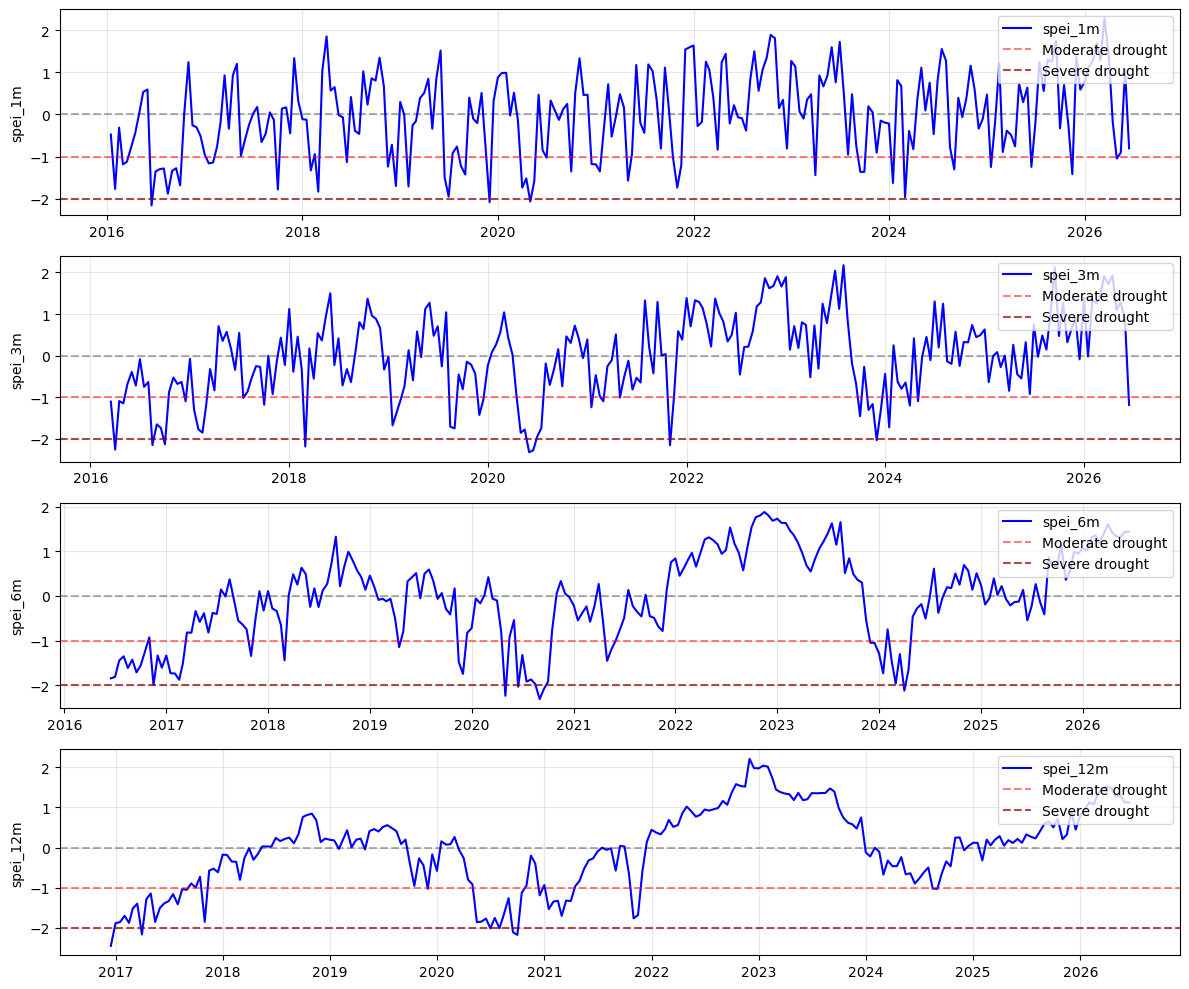

In [4]:
import matplotlib.pyplot as plt

# Plot SPEI time series
fig, axes = plt.subplots(4, 1, figsize=(12, 10))

for i, col in enumerate(['spei_1m', 'spei_3m', 'spei_6m', 'spei_12m']):
    axes[i].plot(df['period_start'], df[col], label=col, color='b')
    axes[i].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[i].axhline(y=-1, color='r', linestyle='--', alpha=0.5, label='Moderate drought')
    axes[i].axhline(y=-2, color='darkred', linestyle='--', alpha=0.7, label='Severe drought')
    axes[i].set_ylabel(col)
    axes[i].legend(loc='upper right')
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()